# Tape Echo / Tape Delay

A tape echo models a magnetic tape loop between a record head and a playback head.
The mechanical imperfections of the tape transport — **wow** (slow motor-speed drift) and **flutter** (fast capstan eccentricity) — modulate the read position each sample, causing subtle pitch variation on every echo.

| Parameter | Effect |
| --- | --- |
| `delay_time` | Tape-loop length in seconds (50–600 ms is typical) |
| `feedback` | Recirculation gain; 0 = single echo, 0.9 = long decaying tail |
| `flutter_rate` | Fast tape-speed variation in Hz (typically 8–12 Hz) |
| `flutter_depth` | Flutter amplitude in seconds (peak read-position swing) |
| `wow_rate` | Slow tape-speed variation in Hz (typically < 2 Hz) |
| `wow_depth` | Wow amplitude in seconds (peak read-position swing) |
| `saturation` | Soft-clipping drive in the feedback path; 0 = clean, 1 = heavy |

The delay curve applied to each echo pass is:

```
D[n] = delay_time · fs
     + wow_depth · fs · sin(2π · wow_rate · n / fs)
     + flutter_depth · fs · sin(2π · flutter_rate · n / fs)
```

Because all echoes traverse the same physical tape, the same `D[n]` curve is applied on every feedback iteration — each repeat hears identical wow/flutter.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt

from python.delay import tape_delay
from python.delay.line import fractional_delay_line

FS = 44100

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## Single Echo Accuracy (feedback = 0)

With `feedback=0`, `wow_depth=0`, and `flutter_depth=0` the output is a single
fractional-delay echo. The peak must land at exactly `delay_time × fs` samples.

Expected peak at sample 4410 (100 ms)
Actual peak at sample   4410 (100.000 ms)
Echo amplitude: 1.000000  (expected 1.0)


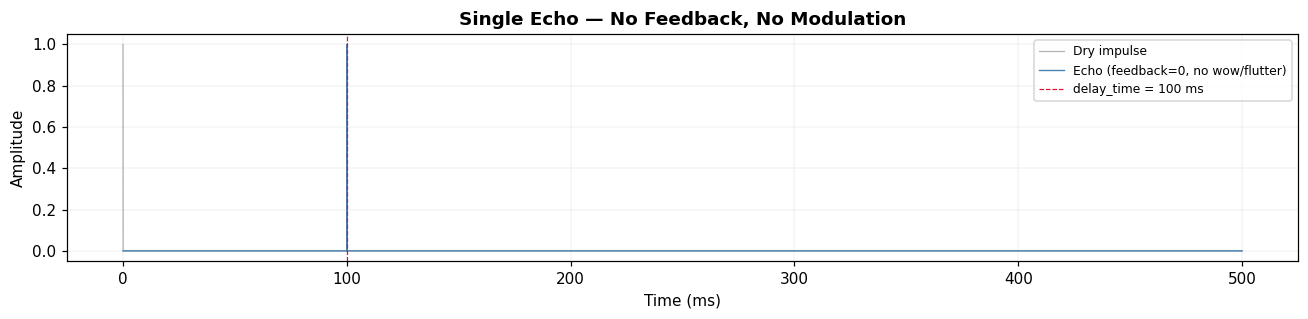

In [2]:
DELAY_TIME = 0.1   # 4410 samples — integer at 44100 Hz
N = int(0.5 * FS)
impulse = np.zeros(N)
impulse[0] = 1.0
t_ms = np.arange(N) / FS * 1000

_, echo = tape_delay(
    impulse, FS,
    delay_time=DELAY_TIME, feedback=0.0,
    flutter_depth=0.0, wow_depth=0.0, saturation=0.0,
)

peak_idx = int(np.argmax(np.abs(echo)))
expected_idx = int(DELAY_TIME * FS)

print(f'Expected peak at sample {expected_idx} ({DELAY_TIME*1000:.0f} ms)')
print(f'Actual peak at sample   {peak_idx} ({peak_idx/FS*1000:.3f} ms)')
print(f'Echo amplitude: {echo[peak_idx]:.6f}  (expected 1.0)')

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t_ms, impulse, color='gray', linewidth=0.8, alpha=0.6, label='Dry impulse')
ax.plot(t_ms, echo, color='steelblue', linewidth=0.9, label='Echo (feedback=0, no wow/flutter)')
ax.axvline(DELAY_TIME * 1000, color='crimson', linewidth=0.8, linestyle='--',
           label=f'delay_time = {DELAY_TIME*1000:.0f} ms')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Amplitude')
ax.set_title('Single Echo — No Feedback, No Modulation', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, linewidth=0.3, alpha=0.4)
plt.tight_layout()
plt.show()

## Feedback Sweep — Echo Trail

Higher `feedback` produces a longer, more decaying echo tail. Wow and flutter are
kept small here so the envelope shape is clear.

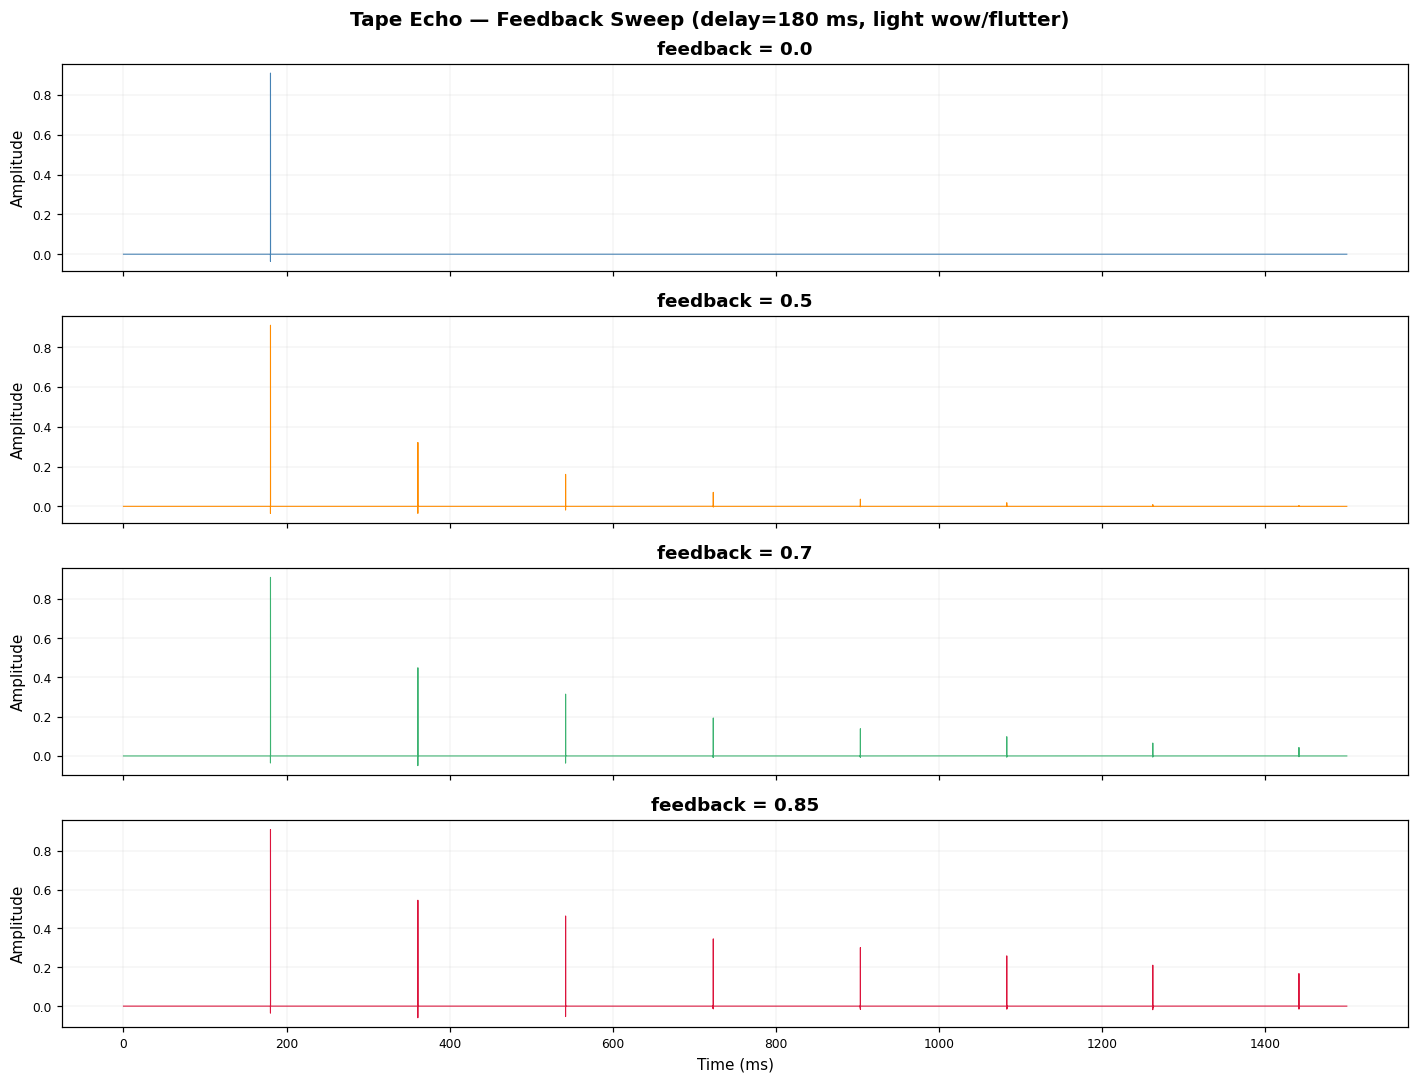

In [3]:
FEEDBACKS = [0.0, 0.5, 0.7, 0.85]
N2 = int(1.5 * FS)
impulse2 = np.zeros(N2)
impulse2[0] = 1.0
t_ms2 = np.arange(N2) / FS * 1000

fig, axes = plt.subplots(len(FEEDBACKS), 1, figsize=(13, 10), sharex=True)
colors = ['steelblue', 'darkorange', 'mediumseagreen', 'crimson']

for ax, fb, color in zip(axes, FEEDBACKS, colors):
    _, echo = tape_delay(
        impulse2, FS,
        delay_time=0.18, feedback=fb,
        flutter_rate=10.0, flutter_depth=0.0003,
        wow_rate=0.5, wow_depth=0.001,
        saturation=0.0,
    )
    ax.plot(t_ms2, echo, color=color, linewidth=0.7)
    ax.set_ylabel('Amplitude')
    ax.set_title(f'feedback = {fb}', fontweight='bold')
    ax.grid(True, linewidth=0.3, alpha=0.4)
    ax.tick_params(labelsize=8)

axes[-1].set_xlabel('Time (ms)')
fig.suptitle(
    'Tape Echo — Feedback Sweep (delay=180 ms, light wow/flutter)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

## Wow and Flutter — Spectrogram Smearing

Wow and flutter create instantaneous pitch shifts on every echo. For sinusoidal
modulation at rate `r` and depth `d` seconds the peak frequency deviation is:

```
|Δf|_peak ≈ f × 2π × r × d
```

A 440 Hz tone with flutter at 10 Hz and depth 1 ms gives **±27.6 Hz** peak deviation —
visible as vertical smearing in the spectrogram.

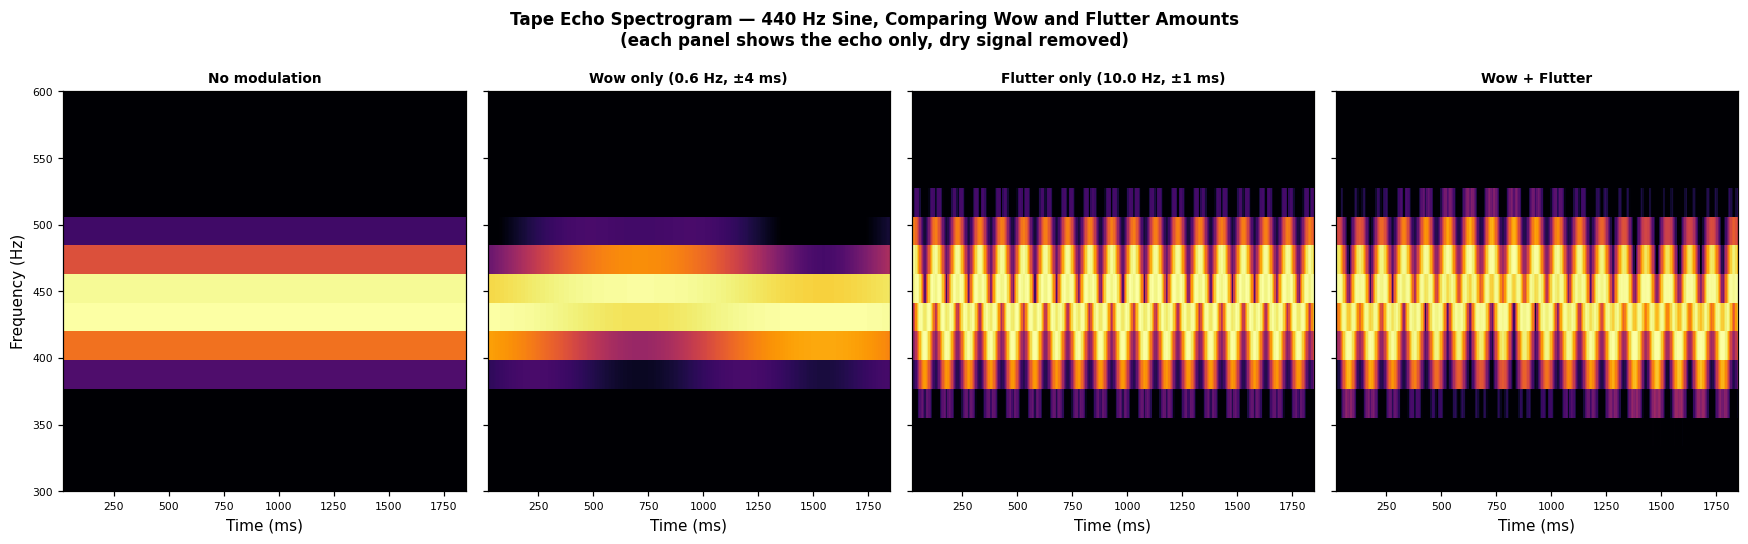

In [4]:
FREQ = 440.0
DURATION_WF = 2.0
N_WF = int(DURATION_WF * FS)
t_wf = np.arange(N_WF) / FS
sine = np.sin(2 * np.pi * FREQ * t_wf)

FLUTTER_RATE  = 10.0
FLUTTER_DEPTH = 0.001   # 1 ms → ±27.6 Hz at 440 Hz
WOW_RATE      = 0.6
WOW_DEPTH     = 0.004   # 4 ms → ±11 Hz at 440 Hz

_, echo_clean = tape_delay(
    sine, FS,
    delay_time=0.1, feedback=0.0,
    flutter_depth=0.0, wow_depth=0.0,
)
_, echo_wow = tape_delay(
    sine, FS,
    delay_time=0.1, feedback=0.0,
    flutter_depth=0.0, wow_rate=WOW_RATE, wow_depth=WOW_DEPTH,
)
_, echo_flutter = tape_delay(
    sine, FS,
    delay_time=0.1, feedback=0.0,
    flutter_rate=FLUTTER_RATE, flutter_depth=FLUTTER_DEPTH, wow_depth=0.0,
)
_, echo_both = tape_delay(
    sine, FS,
    delay_time=0.1, feedback=0.0,
    flutter_rate=FLUTTER_RATE, flutter_depth=FLUTTER_DEPTH,
    wow_rate=WOW_RATE, wow_depth=WOW_DEPTH,
)

def spectrogram(sig, win=2048, hop=256):
    window = np.hanning(win)
    n_frames = (len(sig) - win) // hop
    spec = np.zeros((win // 2 + 1, n_frames))
    for i in range(n_frames):
        frame = sig[i * hop: i * hop + win] * window
        spec[:, i] = np.abs(np.fft.rfft(frame))
    times = (np.arange(n_frames) * hop + win // 2) / FS * 1000
    freqs = np.fft.rfftfreq(win, 1.0 / FS)
    return times, freqs, spec

skip = int(0.12 * FS)
labels = ['No modulation', f'Wow only ({WOW_RATE} Hz, ±{WOW_DEPTH*1000:.0f} ms)',
          f'Flutter only ({FLUTTER_RATE} Hz, ±{FLUTTER_DEPTH*1000:.0f} ms)',
          'Wow + Flutter']
echoes = [echo_clean, echo_wow, echo_flutter, echo_both]

fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=True)

for ax, echo, label in zip(axes, echoes, labels):
    times, freqs, spec = spectrogram(echo[skip:])
    spec_db = 20 * np.log10(spec + 1e-9)
    spec_db -= spec_db.max()
    ax.pcolormesh(times, freqs, spec_db, vmin=-40, vmax=0, cmap='inferno', shading='auto')
    ax.set_ylim(300, 600)
    ax.set_xlabel('Time (ms)')
    ax.set_title(label, fontsize=9, fontweight='bold')
    ax.tick_params(labelsize=7)

axes[0].set_ylabel('Frequency (Hz)')
fig.suptitle(
    'Tape Echo Spectrogram — 440 Hz Sine, Comparing Wow and Flutter Amounts\n'
    '(each panel shows the echo only, dry signal removed)',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.show()

## Delay Modulation Curve

The per-sample delay `D[n]` combines the nominal delay with the wow and flutter sinusoids.
Zooming to the first 300 ms shows the two oscillation rates clearly.

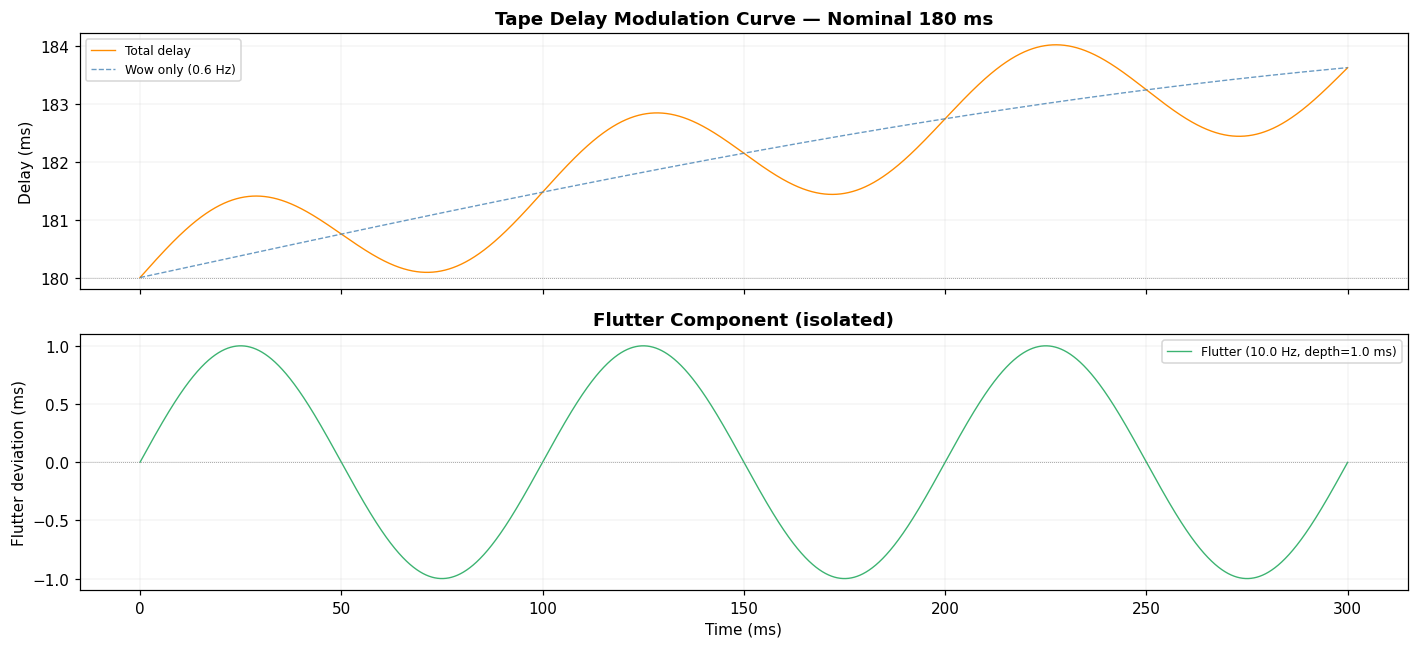

In [5]:
ZOOM_MS = 300
N_ZOOM = int(ZOOM_MS / 1000 * FS)
n_axis = np.arange(N_ZOOM)
t_zoom_ms = n_axis / FS * 1000

NOMINAL_MS = 180.0
wow_ms   = WOW_DEPTH * 1000 * np.sin(2 * np.pi * WOW_RATE * n_axis / FS)
flutter_ms = FLUTTER_DEPTH * 1000 * np.sin(2 * np.pi * FLUTTER_RATE * n_axis / FS)
total_ms = NOMINAL_MS + wow_ms + flutter_ms

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

axes[0].plot(t_zoom_ms, total_ms, color='darkorange', linewidth=0.9, label='Total delay')
axes[0].plot(t_zoom_ms, NOMINAL_MS + wow_ms, color='steelblue', linewidth=0.9,
             linestyle='--', alpha=0.8, label=f'Wow only ({WOW_RATE} Hz)')
axes[0].axhline(NOMINAL_MS, color='gray', linewidth=0.5, linestyle=':')
axes[0].set_ylabel('Delay (ms)')
axes[0].set_title('Tape Delay Modulation Curve — Nominal 180 ms', fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].grid(True, linewidth=0.3, alpha=0.4)

axes[1].plot(t_zoom_ms, flutter_ms, color='mediumseagreen', linewidth=0.9,
             label=f'Flutter ({FLUTTER_RATE} Hz, depth={FLUTTER_DEPTH*1000:.1f} ms)')
axes[1].axhline(0, color='gray', linewidth=0.5, linestyle=':')
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('Flutter deviation (ms)')
axes[1].set_title('Flutter Component (isolated)', fontweight='bold')
axes[1].legend(fontsize=8)
axes[1].grid(True, linewidth=0.3, alpha=0.4)

plt.tight_layout()
plt.show()

## Saturation in the Feedback Path

`saturation` applies `tanh` soft-clipping to the signal before it re-enters the
feedback loop. This prevents runaway growth and adds harmonic richness to later echoes.

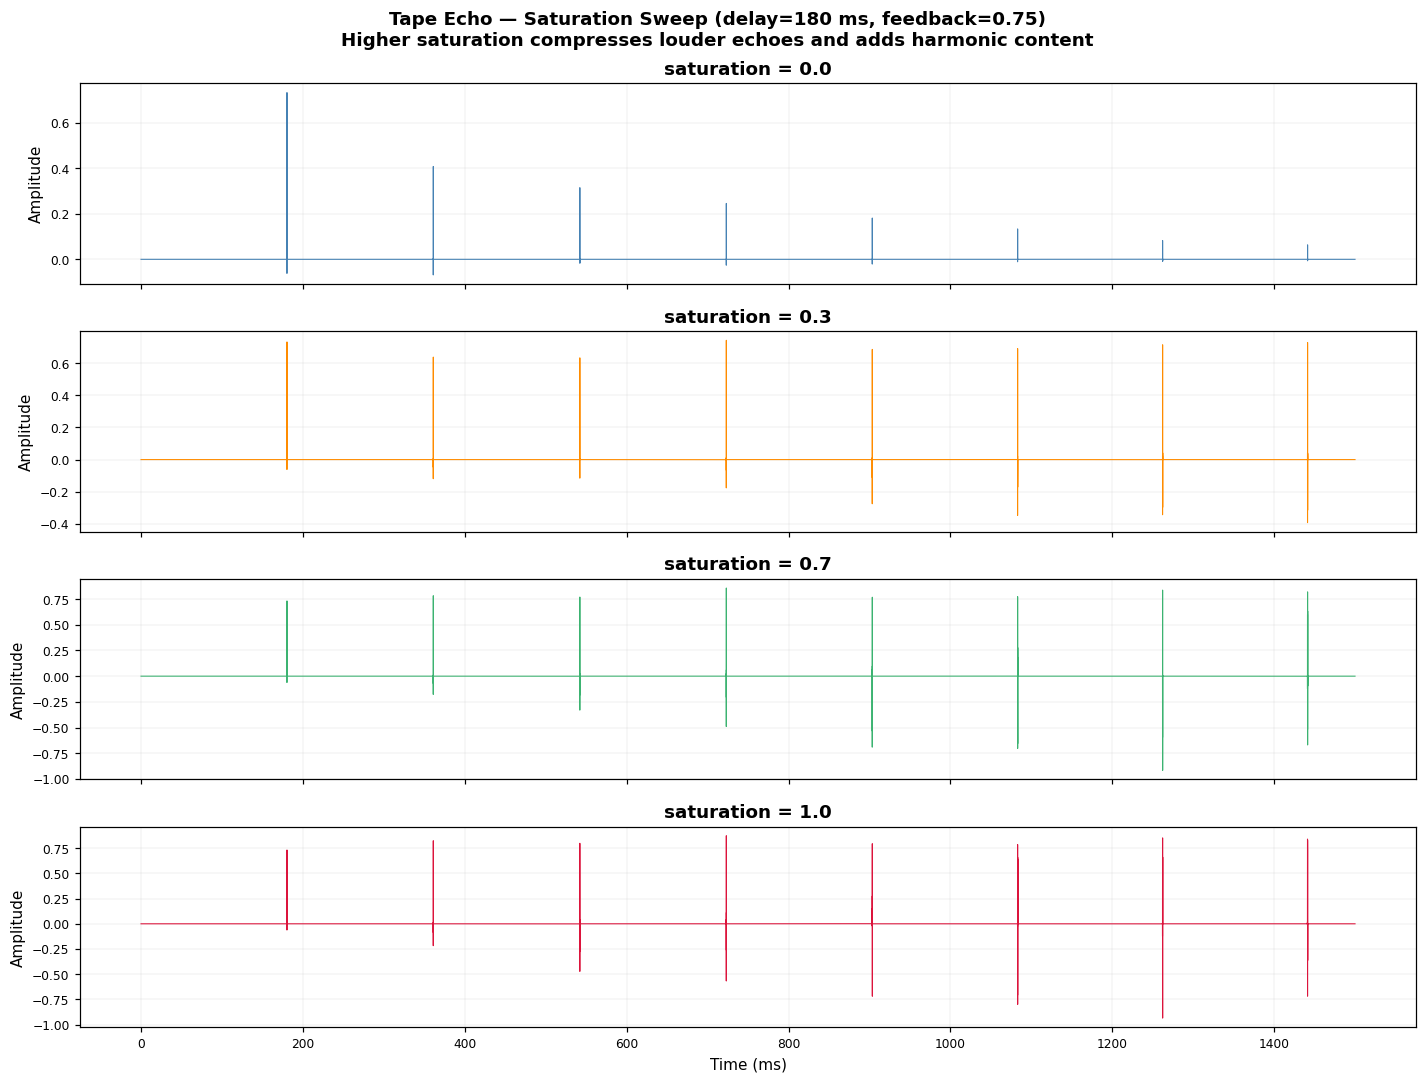

In [6]:
N_SAT = int(1.5 * FS)
impulse_sat = np.zeros(N_SAT)
impulse_sat[0] = 1.0
t_sat_ms = np.arange(N_SAT) / FS * 1000

SAT_LEVELS = [0.0, 0.3, 0.7, 1.0]
colors_sat = ['steelblue', 'darkorange', 'mediumseagreen', 'crimson']

fig, axes = plt.subplots(len(SAT_LEVELS), 1, figsize=(13, 10), sharex=True)

for ax, sat, color in zip(axes, SAT_LEVELS, colors_sat):
    _, echo = tape_delay(
        impulse_sat, FS,
        delay_time=0.18, feedback=0.75,
        flutter_depth=0.0002, wow_depth=0.001,
        saturation=sat,
    )
    ax.plot(t_sat_ms, echo, color=color, linewidth=0.7)
    ax.set_ylabel('Amplitude')
    ax.set_title(f'saturation = {sat}', fontweight='bold')
    ax.grid(True, linewidth=0.3, alpha=0.4)
    ax.tick_params(labelsize=8)

axes[-1].set_xlabel('Time (ms)')
fig.suptitle(
    'Tape Echo — Saturation Sweep (delay=180 ms, feedback=0.75)\n'
    'Higher saturation compresses louder echoes and adds harmonic content',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

## Numerical Verification

Confirm that `feedback=0` with no wow/flutter matches `fractional_delay_line` exactly,
and that `feedback=0.9` produces a finite output.

In [7]:
import numpy as np
from python.delay.line import fractional_delay_line

# --- 1. feedback=0 matches fractional_delay_line ---
N_V = int(0.3 * FS)
rng = np.random.default_rng(0)
sig_v = rng.standard_normal(N_V)

flutter_rate_v, flutter_depth_v = 10.0, 0.0003
wow_rate_v, wow_depth_v = 0.5, 0.001
delay_time_v = 0.05

n_v = np.arange(N_V)
wow_v = wow_depth_v * FS * np.sin(2 * np.pi * wow_rate_v * n_v / FS)
flutter_v = flutter_depth_v * FS * np.sin(2 * np.pi * flutter_rate_v * n_v / FS)
D_v = np.maximum(1.0, delay_time_v * FS + wow_v + flutter_v)
expected_v = fractional_delay_line(sig_v, D_v)

_, out_v = tape_delay(
    sig_v, FS,
    delay_time=delay_time_v, feedback=0.0,
    flutter_rate=flutter_rate_v, flutter_depth=flutter_depth_v,
    wow_rate=wow_rate_v, wow_depth=wow_depth_v,
    saturation=0.0,
)

max_err = np.max(np.abs(out_v - expected_v))
print(f'Match with fractional_delay_line (feedback=0): max error = {max_err:.2e}')
assert max_err < 1e-10, 'Mismatch!'
print('  PASS')

# --- 2. feedback=0.9 → finite output ---
N_V2 = int(1.5 * FS)
impulse_v = np.zeros(N_V2)
impulse_v[0] = 1.0

_, out_v2 = tape_delay(impulse_v, FS, delay_time=0.1, feedback=0.9,
                       flutter_depth=0.0001, wow_depth=0.001)

all_finite = np.all(np.isfinite(out_v2))
print(f'\nfeedback=0.9 output all-finite: {all_finite}')
assert all_finite, 'Non-finite values detected!'
print('  PASS')

# --- 3. Echo peak position ---
DELAY_V = 0.1
N_V3 = int(0.5 * FS)
imp_v3 = np.zeros(N_V3)
imp_v3[0] = 1.0

_, out_v3 = tape_delay(imp_v3, FS, delay_time=DELAY_V, feedback=0.0,
                       flutter_depth=0.0, wow_depth=0.0)

peak = int(np.argmax(np.abs(out_v3)))
expected_peak = int(DELAY_V * FS)
print(f'\nEcho peak at sample {peak}, expected {expected_peak} — offset {peak - expected_peak} samples')
assert abs(peak - expected_peak) <= 2, 'Peak position wrong!'
print('  PASS')

Match with fractional_delay_line (feedback=0): max error = 0.00e+00
  PASS

feedback=0.9 output all-finite: True
  PASS

Echo peak at sample 4410, expected 4410 — offset 0 samples
  PASS
